In [1]:
from signal import signal

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

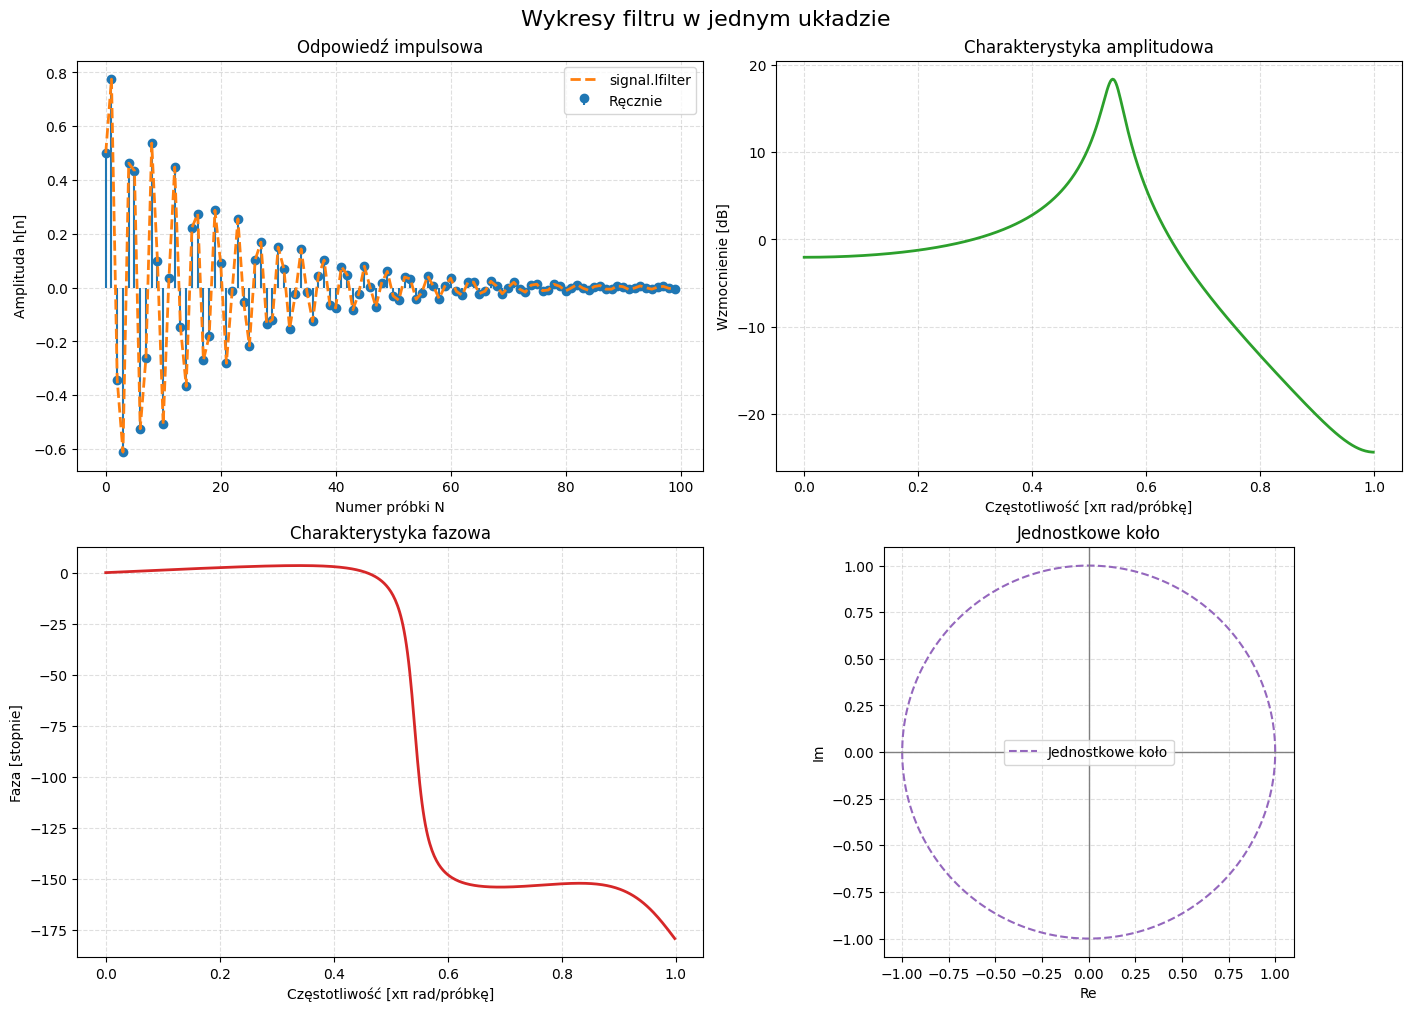

In [20]:
a = [1, 0.25, 0.9]
b = [0.5, 0.9, 0.3]
x = np.zeros(100)
x[0] = 1

y = np.zeros(100)
y[0] = b[0] * x[0]
y[1] = b[0] * x[1] + b[1] * x[0] - a[1] * y[0]

for n in range(2, 100):
    y[n] = b[0] * x[n] + b[1] * x[n-1] + b[2] * x[n-2] - a[1] * y[n-1] - a[2] * y[n-2]

y_lfilter = signal.lfilter(b, a, x)
w, h = signal.freqz(b, a)
w_normalized = w / np.pi

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

n_samples = np.arange(len(y))
axes[0, 0].stem(n_samples, y, basefmt=' ', linefmt='C0-', markerfmt='C0o', label='Ręcznie')
axes[0, 0].plot(n_samples, y_lfilter, 'C1--', linewidth=2, label='signal.lfilter')
axes[0, 0].set_title('Odpowiedź impulsowa')
axes[0, 0].set_xlabel('Numer próbki N')
axes[0, 0].set_ylabel('Amplituda h[n]')
axes[0, 0].grid(True, linestyle='--', alpha=0.4)
axes[0, 0].legend()

amplituda_db = 20 * np.log10(np.maximum(np.abs(h), 1e-12))
axes[0, 1].plot(w_normalized, amplituda_db, color='C2', linewidth=2)
axes[0, 1].set_title('Charakterystyka amplitudowa')
axes[0, 1].set_xlabel('Częstotliwość [xπ rad/próbkę]')
axes[0, 1].set_ylabel('Wzmocnienie [dB]')
axes[0, 1].grid(True, linestyle='--', alpha=0.4)

faza_stopnie = np.unwrap(np.angle(h)) * (180 / np.pi)
axes[1, 0].plot(w_normalized, faza_stopnie, color='C3', linewidth=2)
axes[1, 0].set_title('Charakterystyka fazowa')
axes[1, 0].set_xlabel('Częstotliwość [xπ rad/próbkę]')
axes[1, 0].set_ylabel('Faza [stopnie]')
axes[1, 0].grid(True, linestyle='--', alpha=0.4)

katy = np.linspace(0, 2 * np.pi, 400)
axes[1, 1].plot(np.cos(katy), np.sin(katy), linestyle='--', color='C4', label='Jednostkowe koło')
axes[1, 1].axhline(0, color='0.5', linewidth=1)
axes[1, 1].axvline(0, color='0.5', linewidth=1)
axes[1, 1].set_aspect('equal', adjustable='box')
axes[1, 1].set_title('Jednostkowe koło')
axes[1, 1].set_xlabel('Re')
axes[1, 1].set_ylabel('Im')
axes[1, 1].grid(True, linestyle='--', alpha=0.4)
axes[1, 1].legend()

fig.suptitle('Wykresy filtru w jednym układzie', fontsize=16)
plt.show()